# making a data for our classification!

In [1]:
from sklearn.datasets import make_circles

sample=1000

x , y =make_circles(sample,
                    noise=0.04,
                   )



In [2]:
import pandas as pd 


circle=pd.DataFrame({"X1": x[:, 0],
    "X2": x[:, 1],
    "label": y
})

circle.head()


,X1,X2,label
0,-1.038037,0.211491,0
1,-0.660162,-0.367033,1
2,0.166579,0.972430,0
3,0.641894,0.790774,0
4,-0.796904,-0.490866,0


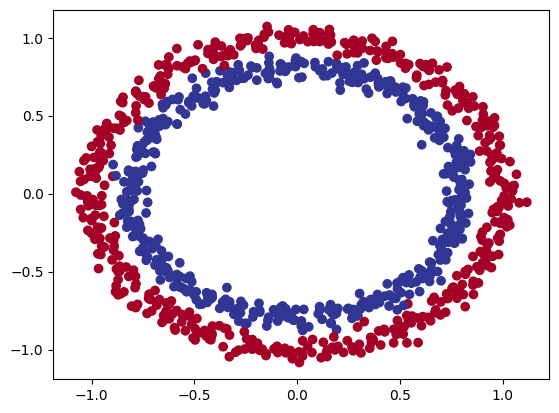

In [3]:
import matplotlib.pyplot as plt

plt.scatter(x=x[:,0],
            y=x[:,1],
            c=y,
            cmap="RdYlBu")

# turning  NP Arr -> Tensors


In [4]:
import torch 

X= torch.from_numpy(x).type(torch.float)
Y=torch.from_numpy(y).type(torch.float)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,
                                                  Y,
                                                  test_size=0.2,
                                                  random_state=42)

# Make the model

In [6]:
import torch 
from torch import nn
device = "cpu"

In [7]:
class Circle(nn.Module):
    def __init__(self):
        super().__init__()
        self.Layer1=nn.Linear(2,5)# first layer 
        self.Layer2=nn.Linear(5,1)# hidden leyer that has output of Y

    def forward(self,x):
        return self.Layer2(self.Layer1(x))

         
model0=Circle().to(device)
model0
        
        

Circle(
  (Layer1): Linear(in_features=2, out_features=5, bias=True)
  (Layer2): Linear(in_features=5, out_features=1, bias=True)
)

# loss function and optimiziation

In [8]:
loss_func=nn.BCEWithLogitsLoss # difference is that this
                               #loss already has sigmoid in it

optim=torch.optim.SGD(params=model0.parameters(),
                      lr=0.1)

# accuracy

In [9]:
def accuracy(real,predict):
    correct_guess=torch.eq(y_true, y_pred).sum().item()
    return (correct_guess/len(predict))*100

## building new model with non linearity applied

In [15]:
#when you start train this model it wont pass 50 percent cause 
# we didnt apply non linearity to our NN and as you can see from our 
# visuall graphs data set is not just a simple linear line 
# thats why we apply non linear function inside our nerual network
class circle2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1=nn.Linear(2,10)
        self.layer2=nn.Linear(10,10)
        self.layer3=nn.Linear(10,1)
        self.relu=nn.ReLU() # our non linear function we could use sigmoid or other 
                            # functions too

    def forward(self,x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))
    

model2=circle2().to(device)
model2


# Setup loss and optimizer 
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model2.parameters(), lr=0.1)




circle2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

# Training time 


In [17]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


for epouch in range(1000):
    # forward
    y_log=model2(X_train).squeeze()
    y_guess=torch.round(torch.sigmoid(y_log)) # if sog >0.5 =1 else 0

    # loss from the guess
    loss=loss_func(y_guess,y_train)
    acc=accuracy(y_guess,y_train)

    # reset grads
    optim.zero_grad()

    # go back to find grads 
    loss.backward()

    # give grads
    optim.step()

    ### now we test our trained data
    
    model2.eval() # change to eval mode
    with torch.inference_mode():
        test_log=model2(X_test).squeeze()
        test_guess=torch.round(torch..sigmoid(test_log))

        test_loss=loss_func(test_log,test_guess)
        test_acc=accuracy(test_log,test_guess)

        

# Multi Class models